Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


58/58 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.0117 - val_loss: 0.0033
Epoch 2/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.8357e-04 - val_loss: 0.0027
Epoch 3/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.3895e-04 - val_loss: 0.0017
Epoch 4/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.4686e-04 - val_loss: 0.0019
Epoch 5/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.4000e-04 - val_loss: 0.0012
Epoch 6/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.2746e-04 - val_loss: 0.0011
Epoch 7/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 3.2844e-04 - val_loss: 0.0011
Epoch 8/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 3.2108e-04 - val_loss: 0.0011
Epoch 9/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 3.2638e-04 - val_loss: 0.0010
Epoch 10/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.1695e-04 - val_loss: 0.0012
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step
RMSE: 1.480874983249545


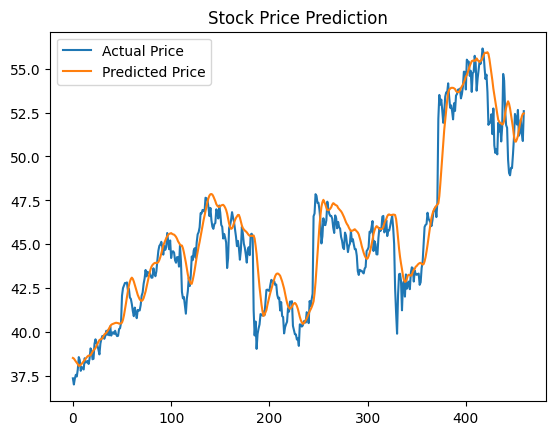

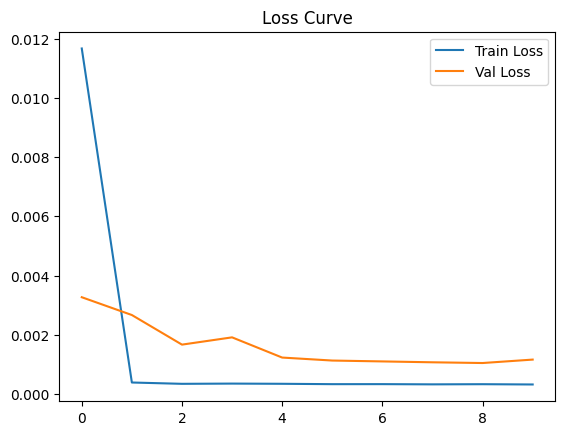

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Load dataset
data = pd.read_csv("stock_price.csv")

# Select closing price (using 'MSFT' as a substitute for 'Close' from the available columns)
dataset = data['MSFT'].values.reshape(-1,1)

# Normalize
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(dataset)

# Create sequence data
X = []
y = []
time_step = 10

for i in range(time_step, len(scaled_data)):
    X.append(scaled_data[i-time_step:i, 0])
    y.append(scaled_data[i, 0])

X, y = np.array(X), np.array(y)

# Reshape for LSTM
X = X.reshape(X.shape[0], X.shape[1], 1)

# Train-test split
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Build LSTM model
model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(X.shape[1],1)),
    LSTM(50),
    Dense(1)
])

# Compile model
model.compile(optimizer='adam', loss='mean_squared_error')

# Train model
history = model.fit(X_train, y_train,
                    epochs=10,
                    batch_size=32,
                    validation_data=(X_test, y_test))

# Predict
predictions = model.predict(X_test)

# Inverse transform
predictions = scaler.inverse_transform(predictions)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1,1))

# RMSE
rmse = np.sqrt(mean_squared_error(y_test_actual, predictions))
print("RMSE:", rmse)

# Plot results
plt.plot(y_test_actual, label="Actual Price")
plt.plot(predictions, label="Predicted Price")
plt.legend()
plt.title("Stock Price Prediction")
plt.show()

# Loss graph
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss Curve")
plt.show()